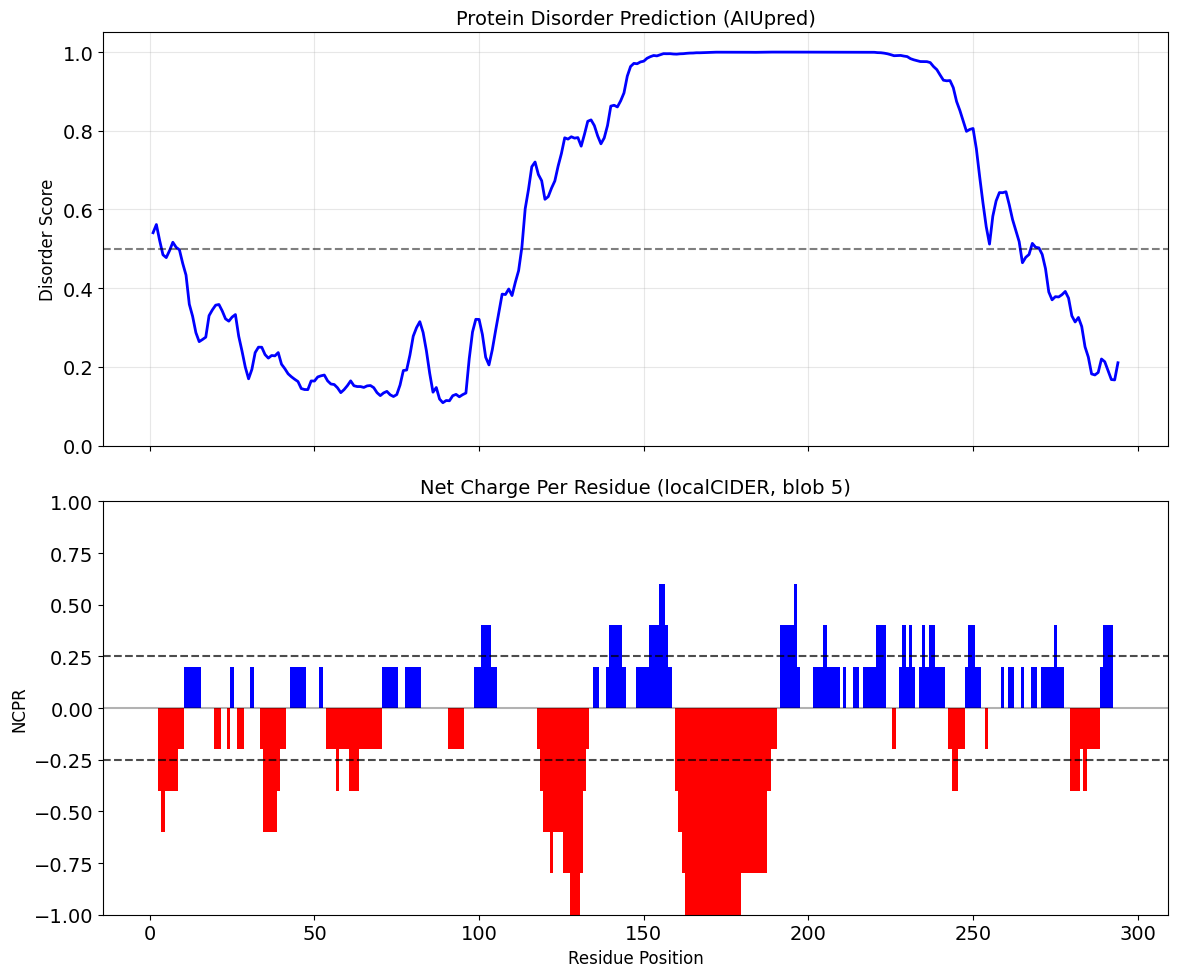

In [ ]:
import sys
import matplotlib.pyplot as plt
import numpy as np
import localcider
from localcider.sequenceParameters import SequenceParameters

# Add AIUPred directory to path
sys.path.append('/home/ilnitsky/tools/AIUPred')
import aiupred_lib

# Define the protein sequence
sequence = "MEDSMDMDMSPLRPQNYLFGCELKADKDYHFKVDNDENEHQLSLRTVSLGAGAKDELHIVEAEAMNYEGSPIKVTLATLKMSVQPTVSLGGFEITPPVVLRLKCGSGPVHISGQHLVAVEEDAESEDEEEEDVKLLSISGKRSAPGGGSKVPQKKVKLAAEEDDEDDDDDDDDDEDDDDDDFDDEETEEKAPVKKSIRDTPAKNAQKSNQNGKDSKPSTPRSKGQESFKKQEKTPKTPKGPTSVEDIKAKMQASIEKGGSLPKVEAKFINYVKNCFRMTDQEAIQDLWQWRKSL"

# For localCIDER, use similar sequence but check for any differences
cider_sequence = "MEDSMDMDMSPLRPQNYLFGCELKADKDYHFKVDNDENEHQLSLRTVSLGAGAKDELHIVEAEAMNYEGSPIKVTLATLKMSVQPTVSLGGFEITPPVVLRLKCGSGPVHISGQHLVAVEEDAESEDEEEEDVKLLSISGKRSAPGGGSKVPQKKVKLAAEEDDEDDDDDDDDDEDDDDDDFDDEETEEKAPVKKSIRDTPAKNAQKSNQNGKDSKPSTPRSKGQESFKKQEKTPKTPKGPTSVEDIKAKMQASIEKGGSLPKVEAKFINYVKNCFRMTDQEAIQDLWQWRKSL"

# Get predictions and data
# AIUpred disorder prediction
disorder_prediction = aiupred_lib.aiupred_disorder(sequence)
positions = range(1, len(sequence) + 1)

# LocalCIDER NCPR data
SeqOb = SequenceParameters(cider_sequence)
ncpr_data = SeqOb.get_linear_NCPR(blobLen=5)
ncpr_x = ncpr_data[0, :]
ncpr_y = ncpr_data[1, :]

# Create figure with two subplots sharing x-axis
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# Plot AIUpred disorder on top subplot
ax1.plot(positions, disorder_prediction, 'b-', linewidth=2)
ax1.set_ylabel('Disorder Score', fontsize=12)
ax1.set_title('Protein Disorder Prediction (AIUpred)', fontsize=14)
ax1.set_ylim([0, 1.05])
ax1.grid(True, alpha=0.3)
ax1.axhline(y=0.5, color='k', linestyle='--', alpha=0.5)  # Optional threshold line

# Plot NCPR on bottom subplot
for i in range(len(ncpr_x)):
    if ncpr_y[i] >= 0:
        ax2.bar(ncpr_x[i], ncpr_y[i], width=1, color='blue', align='center')
    else:
        ax2.bar(ncpr_x[i], ncpr_y[i], width=1, color='red', align='center')

ax2.axhline(y=0, color='k', linestyle='-', alpha=0.3)
ax2.axhline(y=0.25, color='k', linestyle='--', alpha=0.7)
ax2.axhline(y=-0.25, color='k', linestyle='--', alpha=0.7)
ax2.set_xlabel('Residue Position', fontsize=12)
ax2.set_ylabel('NCPR', fontsize=12)
ax2.set_title('Net Charge Per Residue (localCIDER, blob 5)', fontsize=14)
ax2.set_ylim([-1.0, 1.0])

plt.tight_layout()
plt.show()


# To save the combined plot
# plt.savefig('/home/ilnitsky/NPM/combined_plot.png', dpi=300)


In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np
from localcider.sequenceParameters import SequenceParameters
from localcider import plots
from localcider import SequenceFileParserException

# Define paths
fasta_file = "/home/ilnitsky/NPM/fasta/test.fasta"  # Replace with your FASTA file path
output_dir = "/home/ilnitsky/NPM/IUPred_and_localCIDER/all_parameters"  # Replace with your desired output directory
os.makedirs(output_dir, exist_ok=True)

def read_fasta(fasta_file):
    """Read the first sequence from a FASTA file."""
    try:
        with open(fasta_file, 'r') as f:
            lines = f.readlines()
            sequence = ""
            for line in lines:
                if not line.startswith('>'):
                    sequence += line.strip()
            return sequence
    except Exception as e:
        print(f"Error reading FASTA file: {e}")
        return None

def save_plot(fig, filename, output_dir, save_format='png'):
    """Save a matplotlib figure to the output directory."""
    filepath = os.path.join(output_dir, f"{filename}.{save_format}")
    fig.savefig(filepath, dpi=300, format=save_format, bbox_inches='tight')
    plt.close(fig)
    print(f"Saved plot: {filepath}")

# Read sequence from FASTA file
sequence = read_fasta(fasta_file)
if not sequence:
    print("No valid sequence found. Exiting.")
    exit()

# Initialize SequenceParameters object
try:
    SeqOb = SequenceParameters(sequence)
except SequenceFileParserException as e:
    print(f"Error parsing sequence: {e}")
    exit()

# Single-value sequence analysis functions
single_value_functions = [
    ('Length', SeqOb.get_length, {}),
    ('FCR (neutral pH)', SeqOb.get_FCR, {'pH': None}),
    ('NCPR (neutral pH)', SeqOb.get_NCPR, {'pH': None}),
    ('Isoelectric Point', SeqOb.get_isoelectric_point, {}),
    ('Molecular Weight', SeqOb.get_molecular_weight, {}),
    ('Count Negative', SeqOb.get_countNeg, {}),
    ('Count Positive', SeqOb.get_countPos, {}),
    ('Count Neutral', SeqOb.get_countNeut, {}),
    ('Fraction Negative', SeqOb.get_fraction_negative, {}),
    ('Fraction Positive', SeqOb.get_fraction_positive, {}),
    ('Fraction Expanding', SeqOb.get_fraction_expanding, {'pH': None}),
    ('Amino Acid Fractions', SeqOb.get_amino_acid_fractions, {}),
    ('Fraction Disorder Promoting', SeqOb.get_fraction_disorder_promoting, {}),
    ('Kappa', SeqOb.get_kappa, {}),
    ('Omega', SeqOb.get_Omega, {}),
    ('Mean Net Charge', SeqOb.get_mean_net_charge, {'pH': None}),
    ('Phase Plot Region', SeqOb.get_phase_plot_region, {}),
    ('Mean Hydropathy', SeqOb.get_mean_hydropathy, {}),
    ('Uversky Hydropathy', SeqOb.get_uversky_hydropathy, {}),
    ('PPII Propensity (Hilser)', SeqOb.get_PPII_propensity, {'mode': 'hilser'}),
    ('PPII Propensity (Creamer)', SeqOb.get_PPII_propensity, {'mode': 'creamer'}),
    ('PPII Propensity (Kallenbach)', SeqOb.get_PPII_propensity, {'mode': 'kallenbach'}),
    ('Delta', SeqOb.get_delta, {}),
    ('Delta Max', SeqOb.get_deltaMax, {})
]

print("\nSingle-Value Sequence Parameters:")
for name, func, kwargs in single_value_functions:
    try:
        result = func(**kwargs)
        print(f"{name}: {result}")
    except Exception as e:
        print(f"Error computing {name}: {e}")

# Phosphorylation-related functions
phospho_functions = [
    ('Phosphorylatable Sites', SeqOb.get_all_phosphorylatable_sites, {}),
    ('Kappa After Phosphorylation', SeqOb.get_kappa_after_phosphorylation, {}),
    ('Phosphosequence', SeqOb.get_phosphosequence, {})
]

print("\nPhosphorylation-Related Parameters:")
for name, func, kwargs in phospho_functions:
    try:
        result = func(**kwargs)
        print(f"{name}: {result}")
    except Exception as e:
        print(f"Error computing {name}: {e}")

# Position-specific sequence analysis functions
position_specific_functions = [
    ('Linear FCR', SeqOb.get_linear_FCR, {'blobLen': 5}),
    ('Linear NCPR', SeqOb.get_linear_NCPR, {'blobLen': 5}),
    ('Linear Sigma', SeqOb.get_linear_sigma, {'blobLen': 5}),
    ('Linear Hydropathy', SeqOb.get_linear_hydropathy, {'blobLen': 5}),
    ('Linear Complexity (WF)', SeqOb.get_linear_complexity, {'complexityType': 'WF', 'alphabetSize': 20, 'windowSize': 10}),
    ('Linear Complexity (LC)', SeqOb.get_linear_complexity, {'complexityType': 'LC', 'alphabetSize': 20, 'windowSize': 10, 'wordSize': 3}),
    ('Linear Complexity (LZW)', SeqOb.get_linear_complexity, {'complexityType': 'LZW', 'alphabetSize': 20, 'windowSize': 10}),
    ('Linear Composition', SeqOb.get_linear_sequence_composition, {'blobLen': 5}),
    ('Omega Sequence', SeqOb.get_Omega_sequence, {})
]

print("\nPosition-Specific Sequence Parameters:")
for name, func, kwargs in position_specific_functions:
    try:
        result = func(**kwargs)
        print(f"{name}: {result}")
    except Exception as e:
        print(f"Error computing {name}: {e}")

# Plotting functions (save to file)
plotting_functions = [
    ('Phase Diagram', SeqOb.save_phaseDiagramPlot, {'filename': 'phase_diagram', 'saveFormat': 'png'}),
    ('Uversky Plot', SeqOb.save_uverskyPlot, {'filename': 'uversky_plot', 'saveFormat': 'png'}),
    ('Linear Hydropathy', SeqOb.save_linearHydropathy, {'filename': 'linear_hydropathy', 'blobLen': 5, 'saveFormat': 'png'}),
    ('Linear NCPR', SeqOb.save_linearNCPR, {'filename': 'linear_ncpr', 'blobLen': 5, 'saveFormat': 'png'}),
    ('Linear FCR', SeqOb.save_linearFCR, {'filename': 'linear_fcr', 'blobLen': 5, 'saveFormat': 'png'}),
    ('Linear Sigma', SeqOb.save_linearSigma, {'filename': 'linear_sigma', 'blobLen': 5, 'saveFormat': 'png'}),
    ('Linear Complexity (WF)', SeqOb.save_linearComplexity, {'filename': 'linear_complexity_wf', 'complexityType': 'WF', 'alphabetSize': 20, 'windowSize': 10, 'saveFormat': 'png'}),
    ('Linear Complexity (LC)', SeqOb.save_linearComplexity, {'filename': 'linear_complexity_lc', 'complexityType': 'LC', 'alphabetSize': 20, 'windowSize': 10, 'wordSize': 3, 'saveFormat': 'png'}),
    ('Linear Complexity (LZW)', SeqOb.save_linearComplexity, {'filename': 'linear_complexity_lzw', 'complexityType': 'LZW', 'alphabetSize': 20, 'windowSize': 10, 'saveFormat': 'png'}),
    ('Linear Composition', SeqOb.save_linearCoposition, {'filename': 'linear_composition', 'blobLen': 5, 'saveFormat': 'png'})
]

print("\nGenerating Plots:")
for name, func, kwargs in plotting_functions:
    try:
        filename = kwargs['filename']
        kwargs['filename'] = os.path.join(output_dir, filename)
        func(**kwargs)
        print(f"Saved {name} plot to {kwargs['filename']}")
    except Exception as e:
        print(f"Error generating {name} plot: {e}")

# Single and multiple plots using the plots module
print("\nGenerating Plots with Plots Module:")
try:
    # Single phase plot
    fp = SeqOb.get_fraction_positive()
    fn = SeqOb.get_fraction_negative()
    plots.save_single_phasePlot(fp, fn, os.path.join(output_dir, 'single_phase_plot'), saveFormat='png')
    print("Saved single phase plot")

    # Single Uversky plot
    hydropathy = SeqOb.get_uversky_hydropathy()
    mean_net_charge = SeqOb.get_mean_net_charge()
    plots.save_single_uverskyPlot(hydropathy, mean_net_charge, os.path.join(output_dir, 'single_uversky_plot'), saveFormat='png')
    print("Saved single Uversky plot")

    # Multiple plots (example with the same sequence for demonstration)
    plots.save_multiple_phasePlot2([SeqOb], os.path.join(output_dir, 'multiple_phase_plot'), label_list=['Sequence'], saveFormat='png')
    print("Saved multiple phase plot")

    plots.save_multiple_uverskyPlot2([SeqOb], os.path.join(output_dir, 'multiple_uversky_plot'), label_list=['Sequence'], saveFormat='png')
    print("Saved multiple Uversky plot")
except Exception as e:
    print(f"Error generating plots with plots module: {e}")

# Miscellaneous functions
print("\nMiscellaneous Parameters:")
try:
    html_color = SeqOb.get_HTMLColorString()
    print(f"HTML Color String: {html_color}")

    # Example of setting a custom color palette
    color_dict = {aa: 'blue' for aa in 'ACDEFGHIKLMNPQRSTVWY'}  # Simple example
    SeqOb.set_HTMLColorResiduePalette(color_dict)
    custom_html_color = SeqOb.get_HTMLColorString()
    print(f"Custom HTML Color String: {custom_html_color}")

    # Sequence permutation
    shuffled_seq = SeqOb.get_shuffle()
    print(f"Shuffled Sequence Kappa: {shuffled_seq.get_kappa()}")
except Exception as e:
    print(f"Error computing miscellaneous parameters: {e}")

# Phosphorylation distribution (can be computationally expensive for many sites)
try:
    phospho_dist = SeqOb.get_full_phosphostatus_kappa_distribution()
    print("\nPhosphorylation Status Kappa Distribution:")
    for entry in phospho_dist:
        print(entry)
except Exception as e:
    print(f"Error computing phosphorylation distribution: {e}")

print("\nAnalysis complete!")

AttributeError: 'SequenceParameters' object has no attribute 'get_phase_plot_region'

In [3]:
import os
import matplotlib.pyplot as plt
import numpy as np
from localcider.sequenceParameters import SequenceParameters
from localcider import plots
from localcider import SequenceFileParserException

# Define paths
fasta_file = "/home/ilnitsky/NPM/fasta/test.fasta"  # Replace with your FASTA file path
output_dir = "/home/ilnitsky/NPM/IUPred_and_localCIDER/all_parameters"  # Replace with your desired output directory
os.makedirs(output_dir, exist_ok=True)

with open(fasta_file, 'r') as f:
    lines = f.readlines()
    sequence = ""
    for line in lines:
        if not line.startswith('>'):
            sequence += line.strip()

print(sequence)
SeqOb = SequenceParameters(sequence)
print("Length of the sequence: ", SeqOb.get_length())
print("FCR (neutral pH): ", SeqOb.get_FCR(pH=None))
print("NCPR (neutral pH): ", SeqOb.get_NCPR(pH=None))
print("Isoelectric Point: ", SeqOb.get_isoelectric_point())
print("Molecular Weight: ", SeqOb.get_molecular_weight())
print("Count Negative: ", SeqOb.get_countNeg())
print("Count Positive: ", SeqOb.get_countPos())
print("Count Neutral: ", SeqOb.get_countNeut())
print("Fraction Negative: ", SeqOb.get_fraction_negative())
print("Fraction Positive: ", SeqOb.get_fraction_positive())
print("Fraction Expanding: ", SeqOb.get_fraction_expanding(pH=None))
print("Amino Acid Fractions: ", SeqOb.get_amino_acid_fractions())
print("Fraction Disorder Promoting: ", SeqOb.get_fraction_disorder_promoting())
print("Kappa: ", SeqOb.get_kappa())
print("Omega: ", SeqOb.get_Omega())
print("Mean Net Charge: ", SeqOb.get_mean_net_charge(pH=None))
# print("Phase Plot Region: ", SeqOb.get_phase_plot_region())
print("Mean Hydropathy: ", SeqOb.get_mean_hydropathy())
print("Uversky Hydropathy: ", SeqOb.get_uversky_hydropathy())
print("PPII Propensity (Hilser): ", SeqOb.get_PPII_propensity(mode='hilser'))
print("PPII Propensity (Creamer): ", SeqOb.get_PPII_propensity(mode='creamer'))
print("PPII Propensity (Kallenbach): ", SeqOb.get_PPII_propensity(mode='kallenbach'))
print("Delta: ", SeqOb.get_delta())
print("Delta Max: ", SeqOb.get_deltaMax())


fp = SeqOb.get_fraction_positive()
fn = SeqOb.get_fraction_negative()
plots.save_single_phasePlot(fp, fn, os.path.join(output_dir, 'single_phase_plot.png'), saveFormat='png')
print("Saved single phase plot")

# Single Uversky plot
hydropathy = SeqOb.get_uversky_hydropathy()
mean_net_charge = SeqOb.get_mean_net_charge()
plots.save_single_uverskyPlot(hydropathy, mean_net_charge, os.path.join(output_dir, 'single_uversky_plot.png'), saveFormat='png')
print("Saved single Uversky plot")

# Multiple plots (example with the same sequence for demonstration)
plots.save_multiple_phasePlot2([SeqOb], os.path.join(output_dir, 'multiple_phase_plot.png'), label_list=['Sequence'], saveFormat='png')
print("Saved multiple phase plot")

plots.save_multiple_uverskyPlot2([SeqOb], os.path.join(output_dir, 'multiple_uversky_plot.png'), label_list=['Sequence'], saveFormat='png')
print("Saved multiple Uversky plot")




LWATNLEGSAPFKFEGGDNEDEQVIFKSCALGAGAKGKHVIELSAVDANSEKCTVILGVLSDANPYLRLPDISVEPPLLLKLTEGSGPVNVAANHFV
Length of the sequence:  97
FCR (neutral pH):  0.20618556701030927
NCPR (neutral pH):  -0.061855670103092786
Isoelectric Point:  4.375
Molecular Weight:  10207.100000000019
Count Negative:  13
Count Positive:  7
Count Neutral:  77
Fraction Negative:  0.13402061855670103
Fraction Positive:  0.07216494845360824
Fraction Expanding:  0.26804123711340205
Amino Acid Fractions:  {'A': 0.10309278350515463, 'C': 0.020618556701030927, 'D': 0.05154639175257732, 'E': 0.08247422680412371, 'F': 0.041237113402061855, 'G': 0.09278350515463918, 'H': 0.020618556701030927, 'I': 0.041237113402061855, 'K': 0.061855670103092786, 'L': 0.12371134020618557, 'M': 0.0, 'N': 0.061855670103092786, 'P': 0.061855670103092786, 'Q': 0.010309278350515464, 'R': 0.010309278350515464, 'S': 0.07216494845360824, 'T': 0.030927835051546393, 'V': 0.09278350515463918, 'W': 0.010309278350515464, 'Y': 0.010309278350515464}
Fraction D

In [27]:
import pandas as pd
from localcider.sequenceParameters import SequenceParameters
import matplotlib.pyplot as plt
from localcider import plots
import os

# Load data
sheval_npm_profile = pd.read_csv("/home/ilnitsky/NPM/45_Species/NPM_Profile_table_Sheval_NPM1.csv")
output_dir = "/home/ilnitsky/NPM/IUPred_and_localCIDER/all_parameters"
os.makedirs(output_dir, exist_ok=True)

# Extract A1 sequences
a1_seqs = sheval_npm_profile["A1 seq"].dropna()

# Calculate fp and fn for each sequence
seq_objs = [SequenceParameters(seq) for seq in a1_seqs]
fp = [seq.get_fraction_positive() for seq in seq_objs]
fn = [seq.get_fraction_negative() for seq in seq_objs]
labels = [f"A1" for i in range(len(a1_seqs))]

# Set smaller font size
plt.rcParams.update({'font.size': 3, 'axes.labelsize': 3, 'xtick.labelsize': 3, 'ytick.labelsize': 3, 'legend.fontsize': 3, 'figure.figsize': (15, 15), 'legend.loc': 'upper right'})

# Save phase plot
plots.save_multiple_phasePlot2(seq_objs, os.path.join(output_dir, 'a1_phase_plot.png'), label_list=labels, saveFormat='png')
print("Saved A1 phase plot")

Saved A1 phase plot


In [40]:
sheval_npm_profile

,Unnamed: 0,Unnamed: 1,Organism,Uniprot ID,Protein,Gene,"Length, a.a.",N-terminal IDR,N-terminal IDR seq,Unnamed: 9,...,B4,B4 seq,Core of B4,Core of B4 seq,Unnamed: 54,CTD,CTD seq,Unnamed: 57,C-terminal IDR,C-terminal IDR seq
0,Craniata,Synapsida,Homo sapiens,P06748,Nucleophosmin,NPM1,294.0,1-17,MEDSMDMDMSPLRPQNY,NaN,...,NaN,NaN,NaN,NaN,NaN,245-293,EDIKAKMQASIEKGGSLPKVEAKFINYVKNCFRMTDQEAIQDLWQWRKS,NaN,NaN,NaN
1,Craniata,Sauropsida,Gallus gallus,P16039,Nucleophosmin,NPM1,294.0,1-19,MEDSAMDMESMGPLRPQTF,NaN,...,NaN,NaN,NaN,NaN,NaN,245-293,EEIKAKMQASVDKGCSLPKLEPKFANYVKNCFRTEDQKVIQALWQWRQT,NaN,NaN,NaN
2,Craniata,Sauropsida,Anolis carolinensis,G1KRE8,Nucleophosmin,npm1,320.0,1-17,MEDTDMDSMGSLRPQTF,NaN,...,NaN,NaN,NaN,NaN,NaN,247-295,EEIKAKMQAVVQKGTALPKAEAKFANYVKNCYRTEDQKVIQALWQWRQT,NaN,296-320,LHYVRWMMNQIESPWTKFRLIFCLL
3,Craniata,Amphibia,Xaenopus tropicalis,Q6PBF8,Nucleophosmin,npm1,304.0,1-16,MEDSMDMDSIAPLRPQ,NaN,...,NaN,NaN,NaN,NaN,NaN,245-295,KTPLSFDEIKAKMQTSLEKGTVLPKVEVKFANYVKNCFRTENQKVI...,NaN,296-304,WRQSLKDSK
4,Craniata,Osteichthyes,Danio rerio,E7FCU0,Nucleophosmin,npm1a,279.0,1-9,MDLEQMGPQ,NaN,...,NaN,NaN,NaN,NaN,NaN,229-278,ADIKSKMMESVAKGVSLPKVQLKFENYVNNCFKGTDPKVVEELWKW...,NaN,279,K
5,NaN,NaN,NaN,Q566X7,Nucleophosmin,npm1b,307.0,1-19,RLTGPVRAKMEDNIKDLSR,NaN,...,NaN,NaN,NaN,NaN,NaN,253-304,PSLSEVKSKLTSAAKEGKPFPKTEQKFENFARSSFKISDKQVIKDL...,NaN,305-307,LKK
6,Craniata,Chondrichthyes,Callorhinchus milii,K4GBZ8,Nucleophosmin,npm1,310.0,1-16,MEDMSAVESMEALRPQ,NaN,...,NaN,NaN,NaN,NaN,NaN,257-308,EEIKAKLKSSVEKGSGLPKMEQKFTNFIKHGFRVEDPKVVSDLWTW...,NaN,309-310,SK
7,Craniata,Petromyzontida,Petromyzon marinus,A0AAJ7TIJ2,Nucleophosmin-like,LOC116947213,260.0,1-8,MADAKHLS,NaN,...,NaN,NaN,NaN,NaN,NaN,207-258,VADIKATLQQKVEKGVNLPKNKEKFSNFIKSSFKVEDPKVLSELWA...,NaN,259-260,AA
8,Craniata,Myxini,Myxine glutinosa,XP_067967388.1,NaN,NPM3,322.0,1-8,MAETSRPQ,NaN,...,NaN,NaN,NaN,NaN,NaN,269-231,LEDVKTKLKLQMDKGVKMPKKEDKFVNHIKNCFKIEEQKMIKDLWS...,NaN,232,A
9,Craniata,Leptocardii,Branchiostoma lanceolatum,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [34]:
import pandas as pd
from localcider.sequenceParameters import SequenceParameters
import matplotlib.pyplot as plt
from localcider import plots
import os

# Load data
sheval_npm_profile = pd.read_csv("/home/ilnitsky/NPM/45_Species/NPM_Profile_table_Sheval_NPM1.csv")
output_dir = "/home/ilnitsky/NPM/IUPred_and_localCIDER/all_parameters"
os.makedirs(output_dir, exist_ok=True)

# Extract A1, B1 sequences and concatenate
a1_seqs = sheval_npm_profile["A1 seq"].dropna()
b1_seqs = sheval_npm_profile["B1 seq"].dropna()
concat_seqs = [a + b for a, b in zip(a1_seqs, b1_seqs) if not pd.isna(a) and not pd.isna(b)]

# Calculate fp and fn for each sequence set
a1_seq_objs = [SequenceParameters(seq) for seq in a1_seqs]
b1_seq_objs = [SequenceParameters(seq) for seq in b1_seqs]
concat_seq_objs = [SequenceParameters(seq) for seq in concat_seqs]

# Labels
a1_labels = [f"A1" for i in range(len(a1_seqs))]
b1_labels = [f"B1" for i in range(len(b1_seqs))]
concat_labels = [f"A1B1" for i in range(len(concat_seqs))]

# Set smaller font size
plt.rcParams.update({'font.size': 3, 'axes.labelsize': 3, 'xtick.labelsize': 3, 'ytick.labelsize': 3, 'legend.fontsize': 3, 'figure.figsize': (15, 15), 'legend.loc': 'upper right'})

# Save phase plot with all sequences
all_seq_objs = a1_seq_objs + b1_seq_objs + concat_seq_objs
all_labels = a1_labels + b1_labels + concat_labels
plots.save_multiple_phasePlot2(all_seq_objs, os.path.join(output_dir, 'a1_b1_phase_plot.png'), label_list=all_labels, saveFormat='png')





In [39]:
import pandas as pd
from localcider.sequenceParameters import SequenceParameters
import matplotlib.pyplot as plt
from localcider import plots
import os

# Load data
sheval_npm_profile = pd.read_csv("/home/ilnitsky/NPM/45_Species/NPM_Profile_table_Sheval_NPM1.csv")
output_dir = "/home/ilnitsky/NPM/IUPred_and_localCIDER/all_parameters"
os.makedirs(output_dir, exist_ok=True)

# Extract A1, B1 sequences and concatenate
a1_seqs = sheval_npm_profile["A1 seq"].dropna()
b1_seqs = sheval_npm_profile["B1 seq"].dropna()
concat_seqs = [a + b for a, b in zip(a1_seqs, b1_seqs) if not pd.isna(a) and not pd.isna(b)]

# Calculate fp and fn for each sequence set
a1_seq_objs = [SequenceParameters(seq) for seq in a1_seqs]
b1_seq_objs = [SequenceParameters(seq) for seq in b1_seqs]
concat_seq_objs = [SequenceParameters(seq) for seq in concat_seqs]

# Labels
a1_labels = [f"A1" for i in range(len(a1_seqs))]
b1_labels = [f"B1" for i in range(len(b1_seqs))]
concat_labels = [f"A1B1" for i in range(len(concat_seqs))]

# Set smaller font size
plt.rcParams.update({'font.size': 3, 'axes.labelsize': 3, 'xtick.labelsize': 3, 'ytick.labelsize': 3, 'legend.fontsize': 3, 'figure.figsize': (15, 15), 'legend.loc': 'upper right'})

# Save phase plot with all sequences
all_seq_objs = a1_seq_objs + b1_seq_objs + concat_seq_objs
all_labels = a1_labels + b1_labels + concat_labels
plots.save_multiple_phasePlot2(all_seq_objs, os.path.join(output_dir, 'a1_b1_phase_plot.png'), label_list=all_labels, saveFormat='png')



# Customize colors
fp = [obj.get_fraction_positive() for obj in all_seq_objs]
fn = [obj.get_fraction_negative() for obj in all_seq_objs]
a1_end = len(a1_seq_objs)
b1_end = a1_end + len(b1_seq_objs)
plt.rcParams.update({'font.size': 7, 'axes.labelsize': 7, 'xtick.labelsize': 7, 'ytick.labelsize': 7, 'legend.fontsize': 7, 'figure.figsize': (15, 15), 'legend.loc': 'upper right'})

plt.scatter(fp[:a1_end], fn[:a1_end], c='blue', label='A1')
plt.scatter(fp[a1_end:b1_end], fn[a1_end:b1_end], c='green', label='B1')
plt.scatter(fp[b1_end:], fn[b1_end:], c='red', label='A1B1')
#plot labels with each dot
for i, label in enumerate(all_labels):
    plt.annotate(label, (fp[i], fn[i]), fontsize=8)
plt.legend()
plt.savefig(os.path.join(output_dir, 'a1_b1_phase_plot_more.png'))
plt.close()
print("Saved A1, B1, and A1-B1 phase plot")

Saved A1, B1, and A1-B1 phase plot


In [43]:
sheval_npm_profile

,Unnamed: 0,Unnamed: 1,Organism,Uniprot ID,Protein,Gene,"Length, a.a.",N-terminal IDR,N-terminal IDR seq,Unnamed: 9,...,B4,B4 seq,Core of B4,Core of B4 seq,Unnamed: 54,CTD,CTD seq,Unnamed: 57,C-terminal IDR,C-terminal IDR seq
0,Craniata,Synapsida,Homo sapiens,P06748,Nucleophosmin,NPM1,294.0,1-17,MEDSMDMDMSPLRPQNY,NaN,...,NaN,NaN,NaN,NaN,NaN,245-293,EDIKAKMQASIEKGGSLPKVEAKFINYVKNCFRMTDQEAIQDLWQWRKS,NaN,NaN,NaN
1,Craniata,Sauropsida,Gallus gallus,P16039,Nucleophosmin,NPM1,294.0,1-19,MEDSAMDMESMGPLRPQTF,NaN,...,NaN,NaN,NaN,NaN,NaN,245-293,EEIKAKMQASVDKGCSLPKLEPKFANYVKNCFRTEDQKVIQALWQWRQT,NaN,NaN,NaN
2,Craniata,Sauropsida,Anolis carolinensis,G1KRE8,Nucleophosmin,npm1,320.0,1-17,MEDTDMDSMGSLRPQTF,NaN,...,NaN,NaN,NaN,NaN,NaN,247-295,EEIKAKMQAVVQKGTALPKAEAKFANYVKNCYRTEDQKVIQALWQWRQT,NaN,296-320,LHYVRWMMNQIESPWTKFRLIFCLL
3,Craniata,Amphibia,Xaenopus tropicalis,Q6PBF8,Nucleophosmin,npm1,304.0,1-16,MEDSMDMDSIAPLRPQ,NaN,...,NaN,NaN,NaN,NaN,NaN,245-295,KTPLSFDEIKAKMQTSLEKGTVLPKVEVKFANYVKNCFRTENQKVI...,NaN,296-304,WRQSLKDSK
4,Craniata,Osteichthyes,Danio rerio,E7FCU0,Nucleophosmin,npm1a,279.0,1-9,MDLEQMGPQ,NaN,...,NaN,NaN,NaN,NaN,NaN,229-278,ADIKSKMMESVAKGVSLPKVQLKFENYVNNCFKGTDPKVVEELWKW...,NaN,279,K
5,NaN,NaN,NaN,Q566X7,Nucleophosmin,npm1b,307.0,1-19,RLTGPVRAKMEDNIKDLSR,NaN,...,NaN,NaN,NaN,NaN,NaN,253-304,PSLSEVKSKLTSAAKEGKPFPKTEQKFENFARSSFKISDKQVIKDL...,NaN,305-307,LKK
6,Craniata,Chondrichthyes,Callorhinchus milii,K4GBZ8,Nucleophosmin,npm1,310.0,1-16,MEDMSAVESMEALRPQ,NaN,...,NaN,NaN,NaN,NaN,NaN,257-308,EEIKAKLKSSVEKGSGLPKMEQKFTNFIKHGFRVEDPKVVSDLWTW...,NaN,309-310,SK
7,Craniata,Petromyzontida,Petromyzon marinus,A0AAJ7TIJ2,Nucleophosmin-like,LOC116947213,260.0,1-8,MADAKHLS,NaN,...,NaN,NaN,NaN,NaN,NaN,207-258,VADIKATLQQKVEKGVNLPKNKEKFSNFIKSSFKVEDPKVLSELWA...,NaN,259-260,AA
8,Craniata,Myxini,Myxine glutinosa,XP_067967388.1,NaN,NPM3,322.0,1-8,MAETSRPQ,NaN,...,NaN,NaN,NaN,NaN,NaN,269-231,LEDVKTKLKLQMDKGVKMPKKEDKFVNHIKNCFKIEEQKMIKDLWS...,NaN,232,A
9,Craniata,Leptocardii,Branchiostoma lanceolatum,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [44]:
import pandas as pd
from localcider.sequenceParameters import SequenceParameters
import matplotlib.pyplot as plt
from localcider import plots
import os

# Load data
sheval_npm_profile = pd.read_csv("/home/ilnitsky/NPM/45_Species/NPM_Profile_table_Sheval_NPM1.csv")
output_dir = "/home/ilnitsky/NPM/IUPred_and_localCIDER/all_parameters"
os.makedirs(output_dir, exist_ok=True)

# Filter for Craniata
sheval_npm_profile = sheval_npm_profile[sheval_npm_profile['Unnamed: 0'] == 'Craniata']

# Extract A1, A2, B1, B2 sequences and concatenate
a1_seqs = sheval_npm_profile["A1 seq"].dropna()
a2_seqs = sheval_npm_profile["A2 seq"].dropna()
b1_seqs = sheval_npm_profile["B1 seq"].dropna()
b2_seqs = sheval_npm_profile["B2 seq"].dropna()
concat_seqs_a1b1 = [a + b for a, b in zip(a1_seqs, b1_seqs) if not pd.isna(a) and not pd.isna(b)]
concat_seqs_a2b2 = [a + b for a, b in zip(a2_seqs, b2_seqs) if not pd.isna(a) and not pd.isna(b)]

# Calculate fp and fn for each sequence set
a1_seq_objs = [SequenceParameters(seq) for seq in a1_seqs]
a2_seq_objs = [SequenceParameters(seq) for seq in a2_seqs]
b1_seq_objs = [SequenceParameters(seq) for seq in b1_seqs]
b2_seq_objs = [SequenceParameters(seq) for seq in b2_seqs]
concat_seq_objs_a1b1 = [SequenceParameters(seq) for seq in concat_seqs_a1b1]
concat_seq_objs_a2b2 = [SequenceParameters(seq) for seq in concat_seqs_a2b2]

# Labels
a1_labels = [f"A1" for i in range(len(a1_seqs))]
a2_labels = [f"A2" for i in range(len(a2_seqs))]
b1_labels = [f"B1" for i in range(len(b1_seqs))]
b2_labels = [f"B2" for i in range(len(b2_seqs))]
concat_labels_a1b1 = [f"A1B1" for i in range(len(concat_seqs_a1b1))]
concat_labels_a2b2 = [f"A2B2" for i in range(len(concat_seqs_a2b2))]

# Set smaller font size
plt.rcParams.update({'font.size': 3, 'axes.labelsize': 3, 'xtick.labelsize': 3, 'ytick.labelsize': 3, 'legend.fontsize': 3, 'figure.figsize': (15, 15), 'legend.loc': 'upper right'})

# Save phase plot with all sequences
all_seq_objs = a1_seq_objs + a2_seq_objs + b1_seq_objs + b2_seq_objs + concat_seq_objs_a1b1 + concat_seq_objs_a2b2
all_labels = a1_labels + a2_labels + b1_labels + b2_labels + concat_labels_a1b1 + concat_labels_a2b2
plots.save_multiple_phasePlot2(all_seq_objs, os.path.join(output_dir, 'a1_a2_b1_b2_phase_plot.png'), label_list=all_labels, saveFormat='png')

# Customize colors and add labels
fp = [obj.get_fraction_positive() for obj in all_seq_objs]
fn = [obj.get_fraction_negative() for obj in all_seq_objs]
a1_end = len(a1_seq_objs)
a2_end = a1_end + len(a2_seq_objs)
b1_end = a2_end + len(b1_seq_objs)
b2_end = b1_end + len(b2_seq_objs)
a1b1_end = b2_end + len(concat_seq_objs_a1b1)

plt.rcParams.update({'font.size': 7, 'axes.labelsize': 7, 'xtick.labelsize': 7, 'ytick.labelsize': 7, 'legend.fontsize': 7, 'figure.figsize': (15, 15), 'legend.loc': 'upper right'})
plt.scatter(fp[:a1_end], fn[:a1_end], c='blue', label='A1')
plt.scatter(fp[a1_end:a2_end], fn[a1_end:a2_end], c='cyan', label='A2')
plt.scatter(fp[a2_end:b1_end], fn[a2_end:b1_end], c='green', label='B1')
plt.scatter(fp[b1_end:b2_end], fn[b1_end:b2_end], c='lime', label='B2')
plt.scatter(fp[b2_end:a1b1_end], fn[b2_end:a1b1_end], c='red', label='A1B1')
plt.scatter(fp[a1b1_end:], fn[a1b1_end:], c='magenta', label='A2B2')

for i, label in enumerate(all_labels):
    plt.annotate(label, (fp[i], fn[i]), fontsize=8)
plt.legend()
plt.savefig(os.path.join(output_dir, 'a1_a2_b1_b2_phase_plot_more.png'))
plt.close()
print("Saved A1, A2, B1, B2, A1B1, and A2B2 phase plot")

Saved A1, A2, B1, B2, A1B1, and A2B2 phase plot


In [ ]:
import pandas as pd
from localcider.sequenceParameters import SequenceParameters
import matplotlib.pyplot as plt
from localcider import plots
import os

# Load data
sheval_npm_profile = pd.read_csv("/home/ilnitsky/NPM/45_Species/NPM_Profile_table_Sheval_NPM1.csv")
output_dir = "/home/ilnitsky/NPM/IUPred_and_localCIDER/all_parameters"
os.makedirs(output_dir, exist_ok=True)

# Filter for Craniata
sheval_npm_profile = sheval_npm_profile[sheval_npm_profile['Unnamed: 0'] == 'Echinodermata']

# Extract A1, A2, A3, A4, B1, B2, B3, B4 sequences and concatenate
a1_seqs = sheval_npm_profile["A1 seq"].dropna()
a2_seqs = sheval_npm_profile["A2 seq"].dropna()
a3_seqs = sheval_npm_profile["A3 seq"].dropna()
a4_seqs = sheval_npm_profile["A4 seq"].dropna()
b1_seqs = sheval_npm_profile["B1 seq"].dropna()
b2_seqs = sheval_npm_profile["B2 seq"].dropna()
b3_seqs = sheval_npm_profile["B3 seq"].dropna()
b4_seqs = sheval_npm_profile["B4 seq"].dropna()
concat_seqs_a1b1 = [a + b for a, b in zip(a1_seqs, b1_seqs) if not pd.isna(a) and not pd.isna(b)]
concat_seqs_a2b2 = [a + b for a, b in zip(a2_seqs, b2_seqs) if not pd.isna(a) and not pd.isna(b)]
concat_seqs_a3b3 = [a + b for a, b in zip(a3_seqs, b3_seqs) if not pd.isna(a) and not pd.isna(b)]
concat_seqs_a4b4 = [a + b for a, b in zip(a4_seqs, b4_seqs) if not pd.isna(a) and not pd.isna(b)]

# Calculate fp and fn for each sequence set
a1_seq_objs = [SequenceParameters(seq) for seq in a1_seqs]
a2_seq_objs = [SequenceParameters(seq) for seq in a2_seqs]
a3_seq_objs = [SequenceParameters(seq) for seq in a3_seqs]
a4_seq_objs = [SequenceParameters(seq) for seq in a4_seqs]
b1_seq_objs = [SequenceParameters(seq) for seq in b1_seqs]
b2_seq_objs = [SequenceParameters(seq) for seq in b2_seqs]
b3_seq_objs = [SequenceParameters(seq) for seq in b3_seqs]
b4_seq_objs = [SequenceParameters(seq) for seq in b4_seqs]
concat_seq_objs_a1b1 = [SequenceParameters(seq) for seq in concat_seqs_a1b1]
concat_seq_objs_a2b2 = [SequenceParameters(seq) for seq in concat_seqs_a2b2]
concat_seq_objs_a3b3 = [SequenceParameters(seq) for seq in concat_seqs_a3b3]
concat_seq_objs_a4b4 = [SequenceParameters(seq) for seq in concat_seqs_a4b4]

# Labels
a1_labels = [f"A1" for i in range(len(a1_seqs))]
a2_labels = [f"A2" for i in range(len(a2_seqs))]
a3_labels = [f"A3" for i in range(len(a3_seqs))]
a4_labels = [f"A4" for i in range(len(a4_seqs))]
b1_labels = [f"B1" for i in range(len(b1_seqs))]
b2_labels = [f"B2" for i in range(len(b2_seqs))]
b3_labels = [f"B3" for i in range(len(b3_seqs))]
b4_labels = [f"B4" for i in range(len(b4_seqs))]
concat_labels_a1b1 = [f"A1B1" for i in range(len(concat_seqs_a1b1))]
concat_labels_a2b2 = [f"A2B2" for i in range(len(concat_seqs_a2b2))]
concat_labels_a3b3 = [f"A3B3" for i in range(len(concat_seqs_a3b3))]
concat_labels_a4b4 = [f"A4B4" for i in range(len(concat_seqs_a4b4))]

# Set smaller font size
# plt.rcParams.update({'font.size': 3, 'axes.labelsize': 3, 'xtick.labelsize': 3, 'ytick.labelsize': 3, 'legend.fontsize': 3, })

#restore default rcParams
plt.rcParams.update(plt.rcParamsDefault)

# Save phase plot with all sequences
all_seq_objs = (a1_seq_objs + a2_seq_objs + a3_seq_objs + a4_seq_objs + 
                b1_seq_objs + b2_seq_objs + b3_seq_objs + b4_seq_objs + 
                concat_seq_objs_a1b1 + concat_seq_objs_a2b2 + 
                concat_seq_objs_a3b3 + concat_seq_objs_a4b4)
all_labels = (a1_labels + a2_labels + a3_labels + a4_labels + 
              b1_labels + b2_labels + b3_labels + b4_labels + 
              concat_labels_a1b1 + concat_labels_a2b2 + 
              concat_labels_a3b3 + concat_labels_a4b4)
plots.save_multiple_phasePlot2(all_seq_objs, os.path.join(output_dir, 'all_phase_plot.png'), label_list=all_labels, saveFormat='png')

# Customize colors and add labels
fp = [obj.get_fraction_positive() for obj in all_seq_objs]
fn = [obj.get_fraction_negative() for obj in all_seq_objs]
a1_end = len(a1_seq_objs)
a2_end = a1_end + len(a2_seq_objs)
a3_end = a2_end + len(a3_seq_objs)
a4_end = a3_end + len(a4_seq_objs)
b1_end = a4_end + len(b1_seq_objs)
b2_end = b1_end + len(b2_seq_objs)
b3_end = b2_end + len(b3_seq_objs)
b4_end = b3_end + len(b4_seq_objs)
a1b1_end = b4_end + len(concat_seq_objs_a1b1)
a2b2_end = a1b1_end + len(concat_seq_objs_a2b2)
a3b3_end = a2b2_end + len(concat_seq_objs_a3b3)

# plt.rcParams.update({'font.size': 3, 'axes.labelsize': 3, 'xtick.labelsize': 3, 'ytick.labelsize': 3, 'legend.fontsize': 3, 'figure.figsize': (12, 12), 'legend.loc': 'upper right'})
plt.scatter(fp[:a1_end], fn[:a1_end], c='blue', label='A1')
plt.scatter(fp[a1_end:a2_end], fn[a1_end:a2_end], c='cyan', label='A2')
plt.scatter(fp[a2_end:a3_end], fn[a2_end:a3_end], c='purple', label='A3')
plt.scatter(fp[a3_end:a4_end], fn[a3_end:a4_end], c='orange', label='A4')
plt.scatter(fp[a4_end:b1_end], fn[a4_end:b1_end], c='green', label='B1')
plt.scatter(fp[b1_end:b2_end], fn[b1_end:b2_end], c='lime', label='B2')
plt.scatter(fp[b2_end:b3_end], fn[b2_end:b3_end], c='yellow', label='B3')
plt.scatter(fp[b3_end:b4_end], fn[b3_end:b4_end], c='pink', label='B4')
plt.scatter(fp[b4_end:a1b1_end], fn[b4_end:a1b1_end], c='red', label='A1B1')
plt.scatter(fp[a1b1_end:a2b2_end], fn[a1b1_end:a2b2_end], c='magenta', label='A2B2')
plt.scatter(fp[a2b2_end:a3b3_end], fn[a2b2_end:a3b3_end], c='brown', label='A3B3')
plt.scatter(fp[a3b3_end:], fn[a3b3_end:], c='gray', label='A4B4')

for i, label in enumerate(all_labels):
    plt.annotate(label, (fp[i], fn[i]), fontsize=8)
#plot from 0 to 1
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend()
plt.savefig(os.path.join(output_dir, 'all_phase_plot_more.png'))
plt.close()
print("Saved all phase plot")

Saved all phase plot
